In [1]:
import pandas as pd
df=pd.read_csv('all-data.csv',encoding='latin1')
df.head()

,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ."
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [2]:
print(df.isnull().sum())

neutral                                                                                                                            0
According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .    0
dtype: int64


In [3]:
# print(df['According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .'].value_counts())
print(df['According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .'].nunique())
df['According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .']

4837


0       Technopolis plans to develop in stages an area...
1       The international electronic industry company ...
2       With the new production plant the company woul...
3       According to the company 's updated strategy f...
4       FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...
                              ...                        
4840    LONDON MarketWatch -- Share prices ended lower...
4841    Rinkuskiai 's beer sales fell by 6.5 per cent ...
4842    Operating profit fell to EUR 35.4 mn from EUR ...
4843    Net sales of the Paper segment decreased to EU...
4844    Sales in Finland decreased by 10.5 % in Januar...
Name: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ., Length: 4845, dtype: str

In [4]:
df['neutral'].nunique()
print(df['neutral'].value_counts())

neutral
neutral     2878
positive    1363
negative     604
Name: count, dtype: int64


In [5]:
import re
def transform(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z\s]','',text)
    text=re.sub(r'\s+',' ',text)
    return text.strip()
df['text']=df['According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .'].apply(transform)

In [6]:
# df['According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .']
df['text']

0       technopolis plans to develop in stages an area...
1       the international electronic industry company ...
2       with the new production plant the company woul...
3       according to the company s updated strategy fo...
4       financing of aspocomp s growth aspocomp is agg...
                              ...                        
4840    london marketwatch share prices ended lower in...
4841    rinkuskiai s beer sales fell by per cent to mi...
4842    operating profit fell to eur mn from eur mn in...
4843    net sales of the paper segment decreased to eu...
4844    sales in finland decreased by in january while...
Name: text, Length: 4845, dtype: str

In [7]:
# from sklearn.feature_selection import RFE,RFECV,_rfe
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(
    stop_words='english', # removes common words is for this,etc
    max_features=1000 # considers top 3000 important words based on Tf(Term Frequency) and idf(Inverse Document Frequency) 
)
x_text=tfidf.fit_transform(df['text'])

In [8]:
print(type(x_text))
print(x_text)

<class 'scipy.sparse._csr.csr_matrix'>
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34645 stored elements and shape (4845, 1000)>
  Coords	Values
  (0, 902)	0.32498946474175966
  (0, 662)	0.2844262903239644
  (0, 229)	0.32498946474175966
  (0, 59)	0.26022944449304736
  (0, 846)	0.31705028588518797
  (0, 610)	0.24197310088953045
  (0, 149)	0.22911600882489938
  (0, 989)	0.31955600407779466
  (0, 900)	0.30423358307021636
  (0, 907)	0.31955600407779466
  (0, 855)	0.3279510256946903
  (0, 786)	0.1556855117376523
  (1, 427)	0.2552420868773708
  (1, 269)	0.28949490904401154
  (1, 421)	0.22882522025194874
  (1, 150)	0.2520221131096353
  (1, 266)	0.2719912135483697
  (1, 274)	0.23228407646704385
  (1, 892)	0.3185562413133384
  (1, 321)	0.2583428300432254
  (1, 254)	0.22719075104243922
  (1, 468)	0.28165895350279296
  (1, 591)	0.25141484376457623
  (1, 988)	0.30461696391311993
  (1, 204)	0.30171641239180036
  :	:
  (4842, 544)	0.6030851298997523
  (4842, 411)	0.2873931282735861

In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['neutral']=le.fit_transform(df['neutral'])

In [10]:
from scipy.sparse import hstack
x=hstack([df[['neutral']].values,x_text])

In [12]:
print(type(x))
print(x.shape)

<class 'scipy.sparse._coo.coo_matrix'>
(4845, 1001)


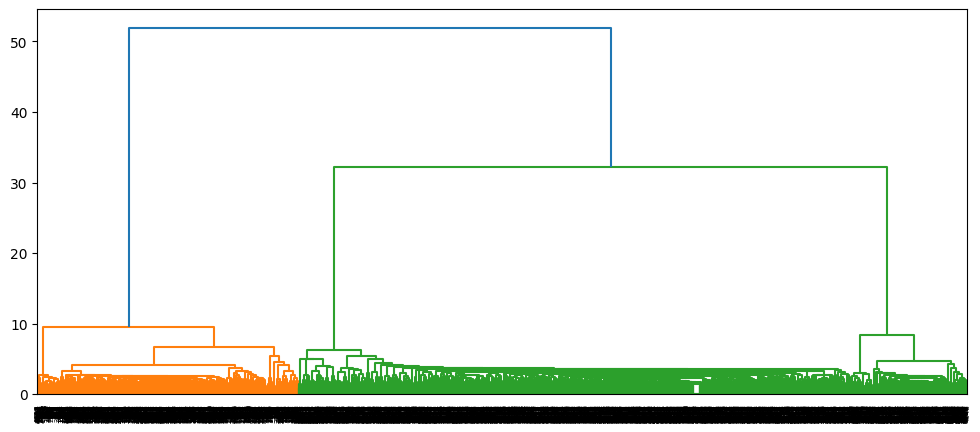

In [13]:
import scipy.cluster.hierarchy as ch
import matplotlib.pyplot as plt

x_dense = x.toarray()

plt.figure(figsize=(12,5))
dend = ch.dendrogram(ch.linkage(x_dense, method='ward'))
plt.show()